# Women's Clothing E-Commerce Reviews: Customer Satisfaction & Product Experience Analysis

# 1. Business Problem

## Problem Definition

In women's fashion e-commerce, customer satisfaction may be influenced by product fit, size, fabric quality, comfort, appearance, and overall wearing experience.

Customer reviews contain detailed information about these experiences, but numerical ratings alone do not explain which product attributes are associated with customer dissatisfaction.

## Business Question

**Which product attributes are associated with customer satisfaction and dissatisfaction?**

## Business Objective

The objective of this project is to identify product attributes associated with customer dissatisfaction and quantify their relationship with customer ratings and recommendation behavior.

## Business Value

The analysis aims to help e-commerce teams identify recurring product-related issues, prioritize areas for product improvement, and better understand the factors associated with customer satisfaction.

# 2. Data Understanding

In this section, the dataset will be explored to understand its overall structure and characteristics. The number of observations and variables, data types, missing values, and basic statistical properties will be examined.
.
.


In [135]:
import pandas as pd
df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [137]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 23486
Number of columns: 11


In [139]:
df.columns.tolist()

['Unnamed: 0',
 'Clothing ID',
 'Age',
 'Title',
 'Review Text',
 'Rating',
 'Recommended IND',
 'Positive Feedback Count',
 'Division Name',
 'Department Name',
 'Class Name']

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


The dataset contains 23,486 observations and 11 variables related to women's clothing products and customer reviews.

The dataset includes numerical variables such as Age, Rating, Recommended IND, and Positive Feedback Count, as well as categorical and text-based variables such as Title, Review Text, Division Name, Department Name, and Class Name.

The Review Text variable is particularly important for this project because customer reviews will be analyzed to identify the main factors associated with customer satisfaction and dissatisfaction.tion.


In [144]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Title              3810
Review Text         845
Division Name        14
Department Name      14
Class Name           14
dtype: int64

The dataset contains missing values in several variables, particularly Title and Review Text. The category-related variables Division Name, Department Name, and Class Name also contain a small number of missing observations.

These missing values will not be handled at this stage. Their treatment will be determined during the Data Cleaning section based on their relevance to the analysis.

In [147]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,23486.0,11742.500000,6779.968547,0.0,5871.25,11742.5,17613.75,23485.0
Clothing ID,23486.0,918.118709,203.298980,0.0,861.00,936.0,1078.00,1205.0
Age,23486.0,43.198544,12.279544,18.0,34.00,41.0,52.00,99.0
Rating,23486.0,4.196032,1.110031,1.0,4.00,5.0,5.00,5.0
Recommended IND,23486.0,0.822362,0.382216,0.0,1.00,1.0,1.00,1.0
Positive Feedback Count,23486.0,2.535936,5.702202,0.0,0.00,1.0,3.00,122.0


Descriptive statistics were examined for the numerical variables to understand their general distribution and characteristics.

Variables such as Age, Rating, and Positive Feedback Count will be explored in greater detail during the Exploratory Data Analysis section.

# 3. Data Cleaning

In this section, the dataset will be prepared for analysis by checking duplicate records, handling missing values, evaluating unnecessary variables, and cleaning the customer review tex.


In [151]:
# Check for duplicate rows
df.duplicated().sum()

0

### 3.1 Duplicate Records

No duplicate records were found in the dataset. Therefore, no observations were removed at this stag.


In [154]:
# Check missing values
df.isnull().sum()

Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

### 3.2 Missing Values

Missing values were identified in five variables: `Title`, `Review Text`, `Division Name`, `Department Name`, and `Class Name`.

The `Review Text` variable contains 845 missing observations. Since review text is essential for the NLP analysis, observations without review text will be excluded only from the review-based analysis rather than being removed from the entire dataset.

The `Title` variable contains 3,810 missing observations and will not be used as a primary variable in the analysis. The categorical variables `Division Name`, `Department Name`, and `Class Name` contain only 14 missing observations each and will be handled appropriately when these variables are used in the analysis.

No observations will be removed from the main dataset solely because of missing values at this stage.

In [157]:
df[['Unnamed: 0', 'Clothing ID']].head(10)

,Unnamed: 0,Clothing ID
0,0,767
1,1,1080
2,2,1077
3,3,1049
4,4,847
5,5,1080
6,6,858
7,7,858
8,8,1077
9,9,1077


In [159]:
# Remove the unnecessary index column
df = df.drop(columns=['Unnamed: 0'])

In [161]:
df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [163]:
df.shape

(23486, 10)

### 3.3 Unnecessary Columns

The `Unnamed: 0` column represents the original row index and does not provide meaningful information for the analysis. Therefore, it was removed from the dataset.

The `Clothing ID` column was retained because it identifies individual products and will be used later to analyze products with the highest number of customer reviews.

In [166]:
df.dtypes

Clothing ID                 int64
Age                         int64
Title                      object
Review Text                object
Rating                      int64
Recommended IND             int64
Positive Feedback Count     int64
Division Name              object
Department Name            object
Class Name                 object
dtype: object

### 3.4 Data Types

The data types of the variables were examined. Numerical variables such as `Age`, `Rating`, `Recommended IND`, and `Positive Feedback Count` are stored as integer values, while text and categorical variables are stored as object values.

The current data types are appropriate for the planned analysis, so no data type conversion is required at this stage.

### 3.5 Review Text Cleaning

Customer reviews contain text that may include missing values, HTML entities, punctuation, inconsistent capitalization, and other unnecessary characters. The review text will be cleaned and standardized before performing the text analysi.


In [170]:
# Create a separate dataset for review analysis
reviews_df = df[df['Review Text'].notna()].copy()

print(f"Original dataset: {len(df)} rows")
print(f"Reviews available for text analysis: {len(reviews_df)} rows")

Original dataset: 23486 rows
Reviews available for text analysis: 22641 rows


In [172]:
import re
import html

reviews_df['clean_review'] = reviews_df['Review Text'].apply(
    lambda x: html.unescape(x).lower()
)

reviews_df[['Review Text', 'clean_review']].head()

,Review Text,clean_review
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful - silky and sexy and comf...
1,Love this dress! it's sooo pretty. i happene...,love this dress! it's sooo pretty. i happene...
2,I had such high hopes for this dress and reall...,i had such high hopes for this dress and reall...
3,"I love, love, love this jumpsuit. it's fun, fl...","i love, love, love this jumpsuit. it's fun, fl..."
4,This shirt is very flattering to all due to th...,this shirt is very flattering to all due to th...


In [174]:
def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)       # Remove HTML tags
    text = re.sub(r'[^a-z\s]', ' ', text)    # Keep letters and spaces only
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    return text

reviews_df['clean_review'] = reviews_df['clean_review'].apply(clean_text)

reviews_df[['Review Text', 'clean_review']].head()

,Review Text,clean_review
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky and sexy and comfor...
1,Love this dress! it's sooo pretty. i happene...,love this dress it s sooo pretty i happened to...
2,I had such high hopes for this dress and reall...,i had such high hopes for this dress and reall...
3,"I love, love, love this jumpsuit. it's fun, fl...",i love love love this jumpsuit it s fun flirty...
4,This shirt is very flattering to all due to th...,this shirt is very flattering to all due to th...


In [176]:
reviews_df[['Review Text', 'clean_review']].head()

,Review Text,clean_review
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky and sexy and comfor...
1,Love this dress! it's sooo pretty. i happene...,love this dress it s sooo pretty i happened to...
2,I had such high hopes for this dress and reall...,i had such high hopes for this dress and reall...
3,"I love, love, love this jumpsuit. it's fun, fl...",i love love love this jumpsuit it s fun flirty...
4,This shirt is very flattering to all due to th...,this shirt is very flattering to all due to th...


In [178]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stopwords = set(ENGLISH_STOP_WORDS)

# Add contraction-related tokens
stopwords.update(['s', 't', 'm'])

def remove_stopwords(text):
    return ' '.join(
        word for word in text.split()
        if word not in stopwords
    )

reviews_df['clean_review'] = reviews_df['clean_review'].apply(remove_stopwords)

In [180]:
# Check the cleaned review dataset
reviews_df[['Review Text', 'clean_review']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 22641 entries, 0 to 23485
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Review Text   22641 non-null  object
 1   clean_review  22641 non-null  object
dtypes: object(2)
memory usage: 530.6+ KB


### Data Cleaning Summary

The data cleaning process was completed by checking duplicate records, handling missing values, removing the unnecessary index column, verifying data types, and preparing customer reviews for text analysis.

No duplicate records were found, and the original dataset was preserved without removing observations due to missing values. A separate dataset containing 22,641 non-null reviews was created for text analysis.

The review text was standardized by converting text to lowercase, removing HTML entities, punctuation, unnecessary characters, and common English stopwords. The resulting `clean_review` variable is ready for further text analysis.nce.

# 4. Exploratory Data Analysis

This section explores the main characteristics of the dataset using descriptive statistics and visualizations.

The analysis focuses on customer ratings, recommendation behavior, customer age, product categories, and review activity to identify important patterns in customer experience.

### 4.1 Customer Rating Distribution

Customer ratings provide an initial measure of customer satisfaction with the products.

The distribution of ratings is examined to understand the overall level of customer satisfaction and whether customers tend to give positive or negative ratings.

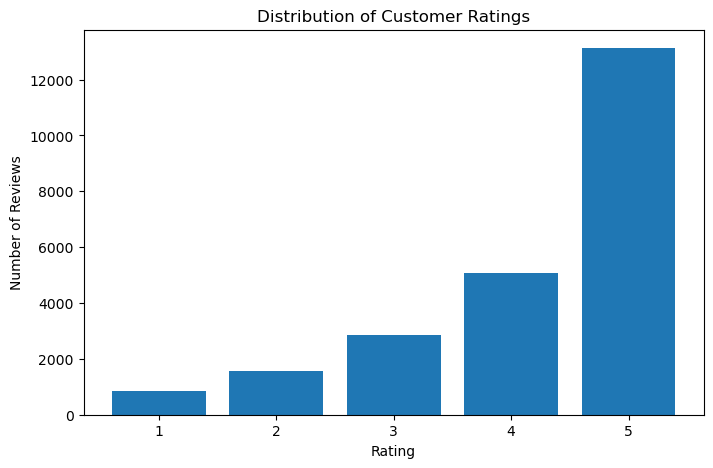

In [185]:
import matplotlib.pyplot as plt

rating_counts = df['Rating'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index, rating_counts.values)

plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.xticks(rating_counts.index)

plt.show()

### 4.2 Recommendation Behavior

The `Recommended IND` variable indicates whether a customer recommends the product.

Analyzing recommendation behavior helps evaluate customer satisfaction from a behavioral perspective and provides a complementary measure to product ratings.

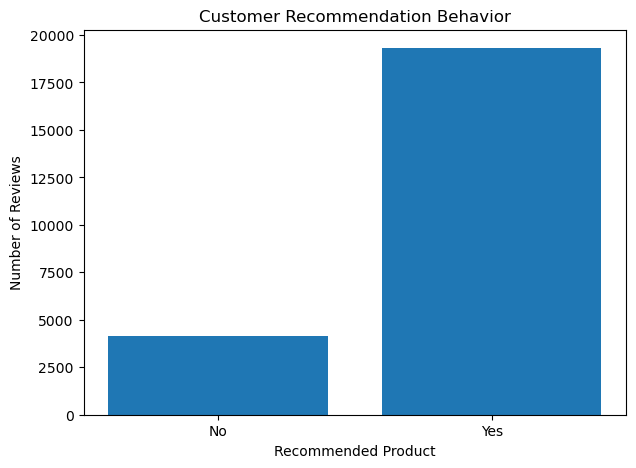

In [188]:
recommendation_counts = df['Recommended IND'].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(recommendation_counts.index, recommendation_counts.values)

plt.title('Customer Recommendation Behavior')
plt.xlabel('Recommended Product')
plt.ylabel('Number of Reviews')
plt.xticks([0, 1], ['No', 'Yes'])

plt.show()

### 4.3 Average Rating by Department

Average customer ratings are compared across product departments to identify differences in customer satisfaction between major product categories.

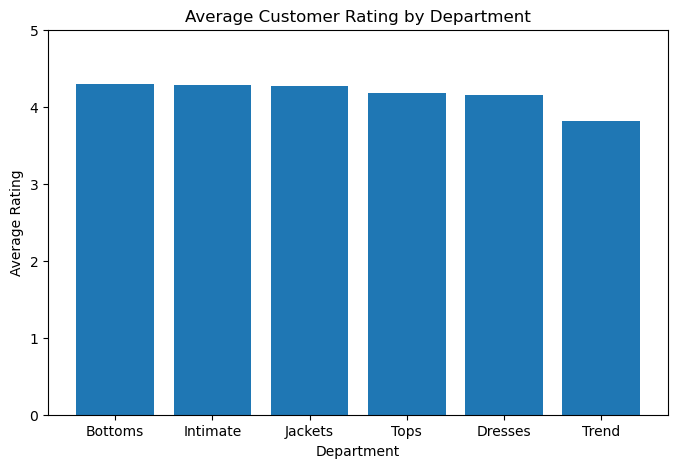

In [191]:
department_rating = (
    df.groupby('Department Name')['Rating']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
plt.bar(department_rating.index, department_rating.values)

plt.title('Average Customer Rating by Department')
plt.xlabel('Department')
plt.ylabel('Average Rating')
plt.ylim(0, 5)

plt.show()

### 4.4 Customer Age Distribution

The age distribution is examined to understand the demographic structure of the customers represented in the dataset.

Grouping customers by age helps identify the main age ranges represented in the reviews and provides context for further analysis of customer satisfaction across different age groups.

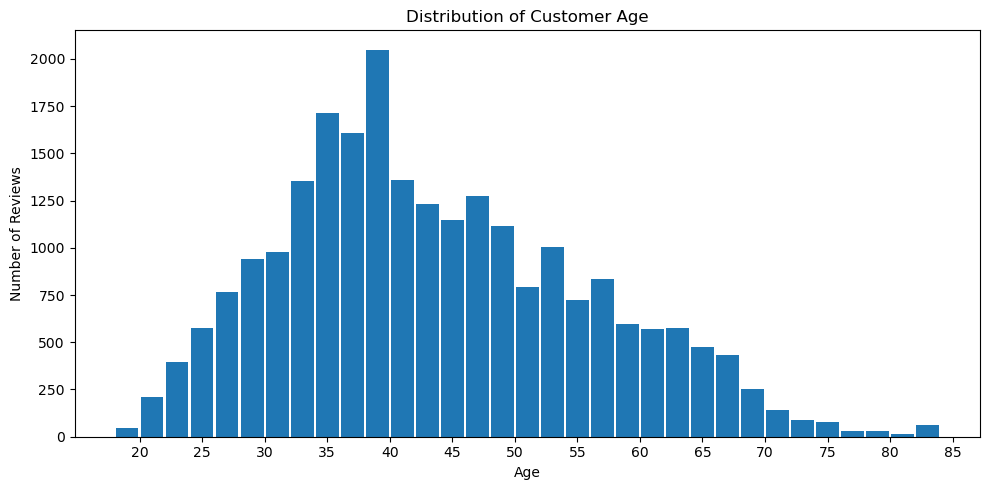

In [194]:
plt.figure(figsize=(10, 5))

plt.hist(
    df['Age'],
    bins=range(18, 86, 2),
    rwidth=0.9
)

plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Number of Reviews')

plt.xticks(range(20, 86, 5))
plt.tight_layout()
plt.show()

### 4.5 Most Reviewed Products

The number of reviews for each product is examined to identify the products with the highest level of customer engagement.

Products with a high number of reviews provide a stronger basis for further product-level analysis because they contain more customer observations.

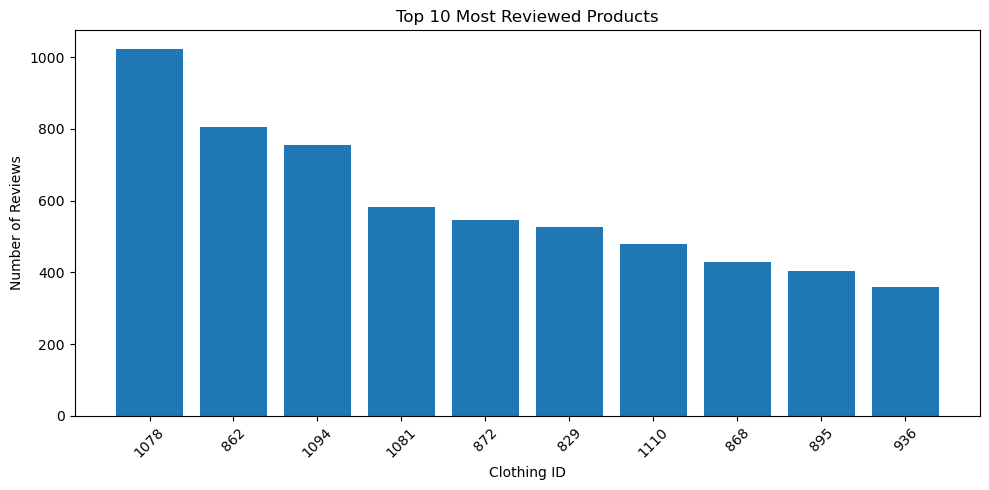

In [197]:
product_review_counts = (
    df['Clothing ID']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 5))

plt.bar(
    product_review_counts.index.astype(str),
    product_review_counts.values
)

plt.title('Top 10 Most Reviewed Products')
plt.xlabel('Clothing ID')
plt.ylabel('Number of Reviews')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [199]:
product_review_counts

Clothing ID
1078    1024
862      806
1094     756
1081     582
872      545
829      527
1110     480
868      430
895      404
936      358
Name: count, dtype: int64

# 5. Review Analysis

Customer reviews contain detailed information about product experiences that cannot be fully captured by numerical ratings alone.

This section analyzes the language used in customer reviews to identify the terms and product-related attributes associated with positive and negative customer experiences.

### 5.1 Overall Review Vocabulary

The most frequent words in customer reviews are examined to understand the main topics and language used by customers.

This provides an initial overview of the review content before comparing positive and negative customer experiences.

In [203]:
from collections import Counter

# Combine all cleaned reviews
all_reviews_text = ' '.join(reviews_df['clean_review'])

# Count word frequencies
word_counts = Counter(all_reviews_text.split())

# Display the 20 most frequent words
top_words = word_counts.most_common(20)

top_words

[('dress', 10567),
 ('love', 8951),
 ('size', 8774),
 ('fit', 7326),
 ('like', 7150),
 ('wear', 6439),
 ('great', 6117),
 ('just', 5608),
 ('fabric', 4798),
 ('small', 4729),
 ('color', 4605),
 ('look', 4039),
 ('really', 3926),
 ('ordered', 3850),
 ('little', 3775),
 ('perfect', 3774),
 ('flattering', 3520),
 ('soft', 3343),
 ('comfortable', 3060),
 ('cute', 3042)]

### 5.2 Positive vs Negative Reviews

To identify differences in customer experience, reviews are divided into positive and negative groups based on their ratings.

Reviews with ratings of 4 or 5 are classified as positive, while reviews with ratings of 1 or 2 are classified as negative. Reviews with a rating of 3 are excluded from this comparison to maintain a clearer distinction between positive and negative experiences.

The vocabulary of the two groups will then be compared to identify terms that are more prominent in positive and negative customer experiences.

In [206]:
# Create positive and negative review groups

positive_reviews = reviews_df[reviews_df['Rating'].isin([4, 5])].copy()
negative_reviews = reviews_df[reviews_df['Rating'].isin([1, 2])].copy()

print(f"Positive reviews: {len(positive_reviews)}")
print(f"Negative reviews: {len(negative_reviews)}")

Positive reviews: 17448
Negative reviews: 2370


In [208]:
# Count word frequencies in positive and negative reviews

positive_word_counts = Counter(
    ' '.join(positive_reviews['clean_review']).split()
)

negative_word_counts = Counter(
    ' '.join(negative_reviews['clean_review']).split()
)

# Display the 20 most frequent words in each group
top_positive_words = positive_word_counts.most_common(20)
top_negative_words = negative_word_counts.most_common(20)

print("Top words in positive reviews:")
print(top_positive_words)

print("\nTop words in negative reviews:")
print(top_negative_words)

Top words in positive reviews:
[('dress', 8036), ('love', 7742), ('size', 7081), ('fit', 5631), ('wear', 5422), ('great', 5417), ('like', 4929), ('just', 4011), ('color', 3634), ('small', 3531), ('perfect', 3517), ('fabric', 3272), ('little', 3246), ('flattering', 2951), ('soft', 2924), ('look', 2840), ('comfortable', 2829), ('really', 2807), ('ordered', 2761), ('fits', 2600)]

Top words in negative reviews:
[('dress', 1123), ('like', 1076), ('fabric', 712), ('fit', 687), ('size', 677), ('just', 667), ('small', 518), ('look', 516), ('ordered', 512), ('really', 474), ('love', 458), ('shirt', 442), ('material', 428), ('wear', 425), ('looks', 400), ('color', 380), ('looked', 376), ('way', 367), ('quality', 339), ('large', 302)]


#### Comparing Word Usage Across Review Groups

Because the number of positive and negative reviews differs substantially, raw word frequencies are not directly comparable.

To account for this difference, word usage is normalized by the number of reviews in each group. This allows us to compare how frequently a word appears within positive and negative reviews.

In [211]:
# Calculate the proportion of reviews containing each word

positive_total = len(positive_reviews)
negative_total = len(negative_reviews)

positive_word_rates = {
    word: count / positive_total
    for word, count in positive_word_counts.items()
}

negative_word_rates = {
    word: count / negative_total
    for word, count in negative_word_counts.items()
}

# Compare the most frequent words in both groups
comparison_words = set(
    list(positive_word_counts.keys()) +
    list(negative_word_counts.keys())
)

word_comparison = pd.DataFrame({
    'word': list(comparison_words),
    'positive_rate': [
        positive_word_rates.get(word, 0)
        for word in comparison_words
    ],
    'negative_rate': [
        negative_word_rates.get(word, 0)
        for word in comparison_words
    ]
})

word_comparison['rate_difference'] = (
    word_comparison['negative_rate'] -
    word_comparison['positive_rate']
)

word_comparison.sort_values(
    'rate_difference',
    ascending=False
).head(20)

,word,positive_rate,negative_rate,rate_difference
9967,like,0.282497,0.454008,0.171512
2642,looked,0.036107,0.158650,0.122542
5194,fabric,0.187529,0.300422,0.112893
11193,disappointed,0.009686,0.107173,0.097487
8527,way,0.061096,0.154852,0.093756
6399,wanted,0.029000,0.108439,0.079438
6072,shirt,0.112334,0.186498,0.074164
12348,material,0.107691,0.180591,0.072899
5553,huge,0.011520,0.083966,0.072446
3804,unfortunately,0.013067,0.082278,0.069211


### 5.2 Result

The comparison between positive and negative reviews shows that customers use different language when describing their product experiences.

Negative reviews contain a higher proportion of terms related to **fabric, material, quality, fit, size, returns, and dissatisfaction**. For example, words such as `fabric`, `material`, `disappointed`, `return`, and `unflattering` appear more frequently in negative reviews relative to the number of reviews in each group.

These findings suggest that product-related attributes may be associated with customer dissatisfaction. However, word-level comparisons alone do not quantify the overall relationship between a specific product attribute and customer satisfaction.

Therefore, the next section groups relevant review terms into broader **product attributes** and examines their relationship with customer ratings and recommendation behavior.

### 5.3 Product Attribute Analysis

The previous analysis identified several product-related terms that appear more frequently in negative reviews.

To investigate these patterns at the product-attribute level, relevant review terms are grouped into broader categories such as **fit, size, fabric and material, comfort, color, length, and quality**.

The analysis will then examine whether reviews mentioning these attributes are associated with different levels of customer satisfaction.

In [215]:
# Define product attribute keywords

attribute_keywords = {
    'Fit': [
        'fit', 'fitting', 'fits', 'flattering', 'unflattering'
    ],
    'Size': [
        'size', 'small', 'large', 'tight', 'loose', 'oversized'
    ],
    'Fabric_Material': [
        'fabric', 'material', 'cotton', 'linen', 'silk', 'polyester'
    ],
    'Comfort': [
        'comfortable', 'comfort', 'soft', 'scratchy', 'itchy'
    ],
    'Color': [
        'color', 'colour', 'black', 'white', 'blue', 'red', 'green'
    ],
    'Length': [
        'length', 'long', 'short', 'hem'
    ],
    'Quality': [
        'quality', 'cheap', 'durable', 'poor', 'wellmade'
    ]
}

attribute_keywords

{'Fit': ['fit', 'fitting', 'fits', 'flattering', 'unflattering'],
 'Size': ['size', 'small', 'large', 'tight', 'loose', 'oversized'],
 'Fabric_Material': ['fabric',
  'material',
  'cotton',
  'linen',
  'silk',
  'polyester'],
 'Comfort': ['comfortable', 'comfort', 'soft', 'scratchy', 'itchy'],
 'Color': ['color', 'colour', 'black', 'white', 'blue', 'red', 'green'],
 'Length': ['length', 'long', 'short', 'hem'],
 'Quality': ['quality', 'cheap', 'durable', 'poor', 'wellmade']}

In [217]:
# Check how often each attribute keyword appears in the reviews

attribute_word_counts = {}

for attribute, keywords in attribute_keywords.items():
    counts = {
        word: word_counts.get(word, 0)
        for word in keywords
    }
    attribute_word_counts[attribute] = counts

attribute_word_counts

{'Fit': {'fit': 7326,
  'fitting': 526,
  'fits': 2856,
  'flattering': 3520,
  'unflattering': 329},
 'Size': {'size': 8774,
  'small': 4729,
  'large': 2842,
  'tight': 1446,
  'loose': 1181,
  'oversized': 261},
 'Fabric_Material': {'fabric': 4798,
  'material': 2765,
  'cotton': 492,
  'linen': 219,
  'silk': 188,
  'polyester': 121},
 'Comfort': {'comfortable': 3060,
  'comfort': 153,
  'soft': 3343,
  'scratchy': 149,
  'itchy': 275},
 'Color': {'color': 4605,
  'colour': 16,
  'black': 1767,
  'white': 1531,
  'blue': 1308,
  'red': 768,
  'green': 769},
 'Length': {'length': 2679, 'long': 2466, 'short': 1915, 'hem': 481},
 'Quality': {'quality': 2297,
  'cheap': 336,
  'durable': 40,
  'poor': 115,
  'wellmade': 1}}

In [219]:
attribute_keywords = {
    'Fit': [
        'fit', 'fitting', 'fits', 'flattering', 'unflattering'
    ],
    'Size': [
        'size', 'small', 'large', 'tight', 'loose', 'oversized'
    ],
    'Fabric_Material': [
        'fabric', 'material', 'cotton', 'linen', 'silk', 'polyester'
    ],
    'Comfort': [
        'comfortable', 'comfort', 'soft', 'scratchy', 'itchy'
    ],
    'Color': [
        'color', 'colour', 'black', 'white', 'blue', 'red', 'green'
    ],
    'Length': [
        'length', 'long', 'short', 'hem'
    ],
    'Quality': [
        'quality', 'cheap', 'durable'
    ]
}

In [221]:
# Create binary indicators for product attributes

for attribute, keywords in attribute_keywords.items():
    pattern = r'\b(?:' + '|'.join(map(re.escape, keywords)) + r')\b'
    
    reviews_df[attribute] = reviews_df['clean_review'].str.contains(
        pattern,
        regex=True,
        na=False
    ).astype(int)

reviews_df[
    list(attribute_keywords.keys())
].head()

,Fit,Size,Fabric_Material,Comfort,Color,Length,Quality
0,0,0,0,1,0,0,0
1,0,0,0,0,0,1,0
2,1,1,0,1,0,0,1
3,0,0,0,0,0,0,0
4,1,0,0,0,0,1,0


In [223]:
# Count the number of reviews mentioning each product attribute

attribute_review_counts = (
    reviews_df[list(attribute_keywords.keys())]
    .sum()
    .sort_values(ascending=False)
)

attribute_review_counts

Fit                10819
Size               10758
Color               6985
Fabric_Material     6980
Comfort             5843
Length              5481
Quality             2477
dtype: int64

In [225]:
# Compare average ratings for reviews mentioning each attribute

attribute_rating_summary = []

for attribute in attribute_keywords.keys():
    mentioned = reviews_df[reviews_df[attribute] == 1]
    not_mentioned = reviews_df[reviews_df[attribute] == 0]
    
    attribute_rating_summary.append({
        'Attribute': attribute,
        'Mentioned_Reviews': len(mentioned),
        'Average_Rating_Mentioned': mentioned['Rating'].mean(),
        'Average_Rating_Not_Mentioned': not_mentioned['Rating'].mean(),
        'Rating_Difference': (
            mentioned['Rating'].mean() - not_mentioned['Rating'].mean()
        )
    })

attribute_rating_summary = pd.DataFrame(attribute_rating_summary)

attribute_rating_summary.sort_values(
    'Rating_Difference'
)

,Attribute,Mentioned_Reviews,Average_Rating_Mentioned,Average_Rating_Not_Mentioned,Rating_Difference
6,Quality,2477,3.894227,4.219103,-0.324876
2,Fabric_Material,6980,4.008596,4.261541,-0.252945
1,Size,10758,4.181075,4.185812,-0.004737
5,Length,5481,4.218026,4.172552,0.045473
0,Fit,10819,4.280802,4.094569,0.186233
4,Color,6985,4.314961,4.124936,0.190025
3,Comfort,5843,4.487421,4.077866,0.409554


In [227]:
# Calculate dissatisfaction rates for each product attribute

dissatisfaction_summary = []

for attribute in attribute_keywords.keys():
    mentioned = reviews_df[reviews_df[attribute] == 1]
    not_mentioned = reviews_df[reviews_df[attribute] == 0]
    
    mentioned_dissatisfaction = (
        mentioned['Rating'].isin([1, 2]).mean() * 100
    )
    
    not_mentioned_dissatisfaction = (
        not_mentioned['Rating'].isin([1, 2]).mean() * 100
    )
    
    dissatisfaction_summary.append({
        'Attribute': attribute,
        'Dissatisfaction_Mentioned_%': mentioned_dissatisfaction,
        'Dissatisfaction_Not_Mentioned_%': not_mentioned_dissatisfaction,
        'Difference_pp': (
            mentioned_dissatisfaction -
            not_mentioned_dissatisfaction
        )
    })

dissatisfaction_summary = pd.DataFrame(dissatisfaction_summary)

dissatisfaction_summary.sort_values(
    'Difference_pp',
    ascending=False
)

,Attribute,Dissatisfaction_Mentioned_%,Dissatisfaction_Not_Mentioned_%,Difference_pp
6,Quality,17.642309,9.586392,8.055918
2,Fabric_Material,13.366762,9.175659,4.191103
1,Size,9.444135,11.394429,-1.950294
5,Length,8.556833,11.078089,-2.521256
0,Fit,8.706905,12.079174,-3.372270
4,Color,7.687903,11.707971,-4.020069
3,Comfort,4.706486,12.471723,-7.765236


In [229]:
# Combine rating and dissatisfaction results

attribute_summary = attribute_rating_summary.merge(
    dissatisfaction_summary,
    on='Attribute'
)

attribute_summary = attribute_summary[
    [
        'Attribute',
        'Mentioned_Reviews',
        'Average_Rating_Mentioned',
        'Average_Rating_Not_Mentioned',
        'Rating_Difference',
        'Dissatisfaction_Mentioned_%',
        'Dissatisfaction_Not_Mentioned_%',
        'Difference_pp'
    ]
]

attribute_summary.sort_values(
    'Difference_pp',
    ascending=False
)

,Attribute,Mentioned_Reviews,Average_Rating_Mentioned,Average_Rating_Not_Mentioned,Rating_Difference,Dissatisfaction_Mentioned_%,Dissatisfaction_Not_Mentioned_%,Difference_pp
6,Quality,2477,3.894227,4.219103,-0.324876,17.642309,9.586392,8.055918
2,Fabric_Material,6980,4.008596,4.261541,-0.252945,13.366762,9.175659,4.191103
1,Size,10758,4.181075,4.185812,-0.004737,9.444135,11.394429,-1.950294
5,Length,5481,4.218026,4.172552,0.045473,8.556833,11.078089,-2.521256
0,Fit,10819,4.280802,4.094569,0.186233,8.706905,12.079174,-3.372270
4,Color,6985,4.314961,4.124936,0.190025,7.687903,11.707971,-4.020069
3,Comfort,5843,4.487421,4.077866,0.409554,4.706486,12.471723,-7.765236


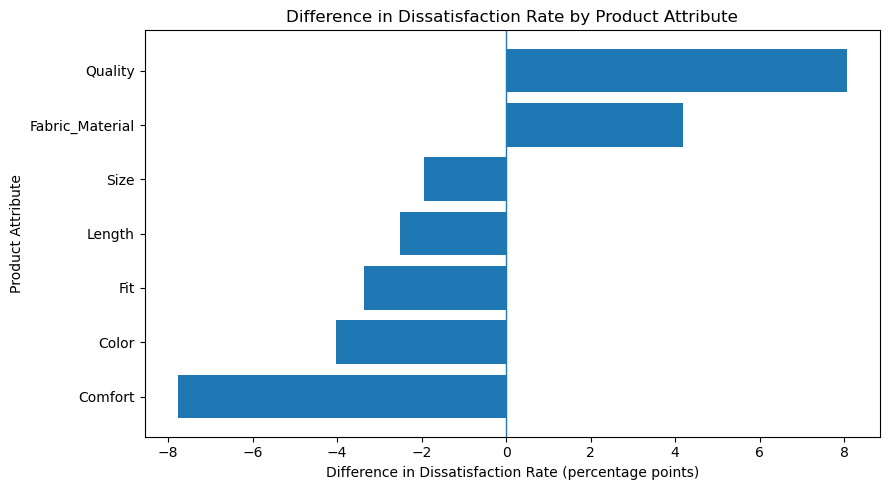

In [231]:
# Visualize the difference in dissatisfaction rates by product attribute

plot_data = attribute_summary.sort_values(
    'Difference_pp',
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    plot_data['Attribute'],
    plot_data['Difference_pp']
)

plt.axvline(0, linewidth=1)

plt.title('Difference in Dissatisfaction Rate by Product Attribute')
plt.xlabel('Difference in Dissatisfaction Rate (percentage points)')
plt.ylabel('Product Attribute')

plt.tight_layout()
plt.show()

#### Attribute-level Customer Experience
The previous analysis showed how reviews mentioning each product attribute differ in average rating and dissatisfaction rate.

To further understand customer experience, reviews mentioning each attribute are classified based on their ratings:

- Ratings of 4 or 5 are classified as **positive**
- A rating of 3 is classified as **neutral**
- Ratings of 1 or 2 are classified as **negative**

The distribution of these customer evaluations is then compared across product attributes to identify which attributes are more frequently associated with positive or negative customer experiences.

In [234]:
# Calculate positive, neutral, and negative rating distributions for each attribute

experience_summary = []

for attribute in attribute_keywords.keys():
    mentioned = reviews_df[reviews_df[attribute] == 1]
    
    positive_rate = mentioned['Rating'].isin([4, 5]).mean() * 100
    neutral_rate = (mentioned['Rating'] == 3).mean() * 100
    negative_rate = mentioned['Rating'].isin([1, 2]).mean() * 100
    
    experience_summary.append({
        'Attribute': attribute,
        'Positive_%': positive_rate,
        'Neutral_%': neutral_rate,
        'Negative_%': negative_rate
    })

experience_summary = pd.DataFrame(experience_summary)

experience_summary

,Attribute,Positive_%,Neutral_%,Negative_%
0,Fit,79.951936,11.341159,8.706905
1,Size,77.309909,13.245956,9.444135
2,Fabric_Material,70.888252,15.744986,13.366762
3,Comfort,87.523532,7.769981,4.706486
4,Color,81.603436,10.708661,7.687903
5,Length,78.835979,12.607188,8.556833
6,Quality,66.047638,16.310052,17.642309


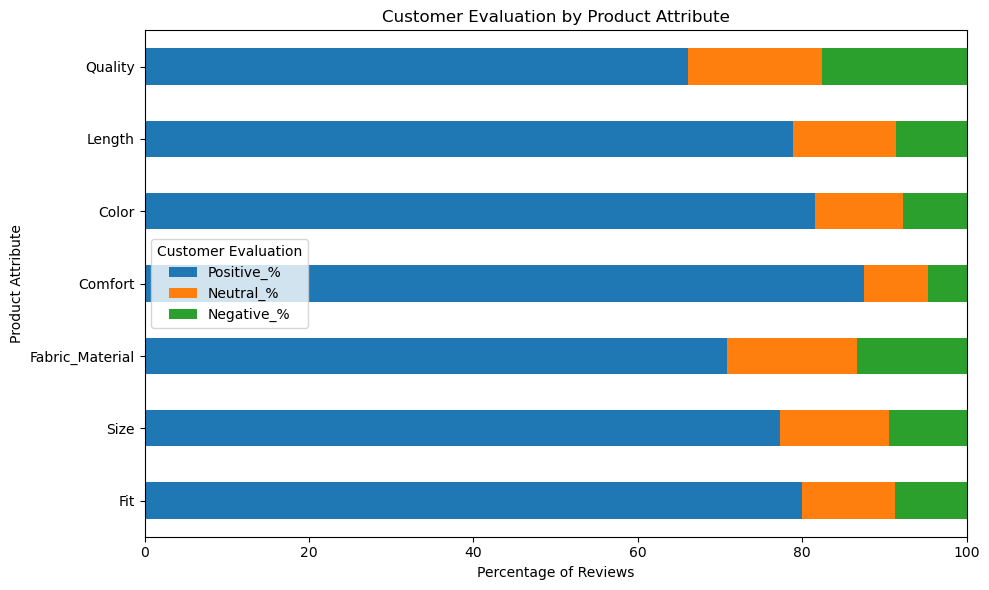

In [236]:
# Visualize customer evaluation by product attribute

plot_data = experience_summary.set_index('Attribute')[
    ['Positive_%', 'Neutral_%', 'Negative_%']
]

ax = plot_data.plot(
    kind='barh',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Customer Evaluation by Product Attribute')
plt.xlabel('Percentage of Reviews')
plt.ylabel('Product Attribute')
plt.xlim(0, 100)
plt.legend(title='Customer Evaluation')

plt.tight_layout()
plt.show()

### 5.3 Result

The attribute-level analysis shows clear differences in customer evaluations across product attributes.

**Quality** stands out as the strongest potential dissatisfaction area. Among reviews mentioning quality, **66.05%** received a positive rating (4–5 stars), while **17.64%** received a negative rating (1–2 stars). The dissatisfaction rate was **8.06 percentage points higher** than among reviews that did not mention quality.

**Fabric and material** also show a relatively unfavorable pattern. Among reviews mentioning these attributes, **70.89%** received a positive rating and **13.37%** received a negative rating. The dissatisfaction rate was **4.19 percentage points higher** than among reviews without these mentions.

In contrast, **comfort** had the most favorable evaluation, with **87.52%** positive and only **4.71%** negative reviews. Fit and color also showed relatively high positive-rating shares.

Overall, **quality and fabric/material are the attributes most strongly associated with customer dissatisfaction, while comfort is associated with a more favorable customer evaluation**.

These results represent associations between attribute mentions and overall review ratings. They do not imply that an attribute directly caused a higher or lower rating. The classification is based on the overall rating of reviews mentioning each attribute rather than sentiment toward the specific attribute itself.

# 6. Statistical Analysis

The exploratory analysis identified differences in dissatisfaction rates between reviews that mention specific product attributes and those that do not.

To determine whether these differences represent statistically significant associations, statistical hypothesis tests are applied.

The main focus is the relationship between product attribute mentions and customer dissatisfaction.

### 6.1 Attribute Mentions and Customer Dissatisfaction

Customer dissatisfaction is defined as a rating of **1 or 2**, while ratings of **3, 4, or 5** are classified as non-dissatisfied reviews.

A **Chi-square test of independence** is used to test whether mentioning a specific product attribute is statistically associated with customer dissatisfaction.

The null hypothesis states that there is **no association** between mentioning the attribute and customer dissatisfaction.

The alternative hypothesis states that there **is an association** between the two variables.

In [241]:
from scipy.stats import chi2_contingency

statistical_results = []

for attribute in attribute_keywords.keys():
    
    contingency_table = pd.crosstab(
        reviews_df[attribute],
        reviews_df['Rating'].isin([1, 2])
    )
    
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    statistical_results.append({
        'Attribute': attribute,
        'Chi2': chi2,
        'p_value': p_value
    })

chi_square_results = pd.DataFrame(statistical_results)

chi_square_results.sort_values('p_value')

,Attribute,Chi2,p_value
3,Comfort,278.089013,1.959017e-62
6,Quality,151.899937,6.663397e-35
2,Fabric_Material,90.043995,2.329225e-21
4,Color,82.860343,8.806028e-20
0,Fit,68.188652,1.485783e-16
5,Length,27.907861,1.272318e-07
1,Size,22.707914,1.885896e-06


In [243]:
from scipy.stats import chi2_contingency

effect_size_results = []

for attribute in attribute_keywords.keys():
    
    contingency_table = pd.crosstab(
        reviews_df[attribute],
        reviews_df['Rating'].isin([1, 2])
    )
    
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    n = contingency_table.values.sum()
    
    # Cramér's V for a 2x2 table
    phi = (chi2 / n) ** 0.5
    
    effect_size_results.append({
        'Attribute': attribute,
        'Chi2': chi2,
        'p_value': p_value,
        'Cramers_V': phi
    })

effect_size_results = pd.DataFrame(effect_size_results)

effect_size_results.sort_values(
    'Cramers_V',
    ascending=False
)

,Attribute,Chi2,p_value,Cramers_V
3,Comfort,278.089013,1.959017e-62,0.110827
6,Quality,151.899937,6.663397e-35,0.081909
2,Fabric_Material,90.043995,2.329225e-21,0.063064
4,Color,82.860343,8.806028e-20,0.060496
0,Fit,68.188652,1.485783e-16,0.054879
5,Length,27.907861,1.272318e-07,0.035109
1,Size,22.707914,1.885896e-06,0.031669


### 6.1 Result

The Chi-square tests indicate statistically significant associations between all examined product attributes and customer dissatisfaction, with all p-values below 0.001.

However, statistical significance does not necessarily indicate a strong relationship. The Cramér's V values show that the associations are relatively small in magnitude.

Among the examined attributes, **Comfort** has the highest association with customer dissatisfaction (Cramér's V = 0.111), followed by **Quality** (V = 0.082) and **Fabric/Material** (V = 0.063).

When these results are considered together with the dissatisfaction rate differences from the previous analysis, **Quality** stands out as an important potential area of dissatisfaction. Reviews mentioning quality had a dissatisfaction rate **8.06 percentage points higher** than reviews that did not mention quality.

Similarly, reviews mentioning **Fabric/Material** had a dissatisfaction rate **4.19 percentage points higher** than reviews without these mentions.

In contrast, reviews mentioning **Comfort** had a dissatisfaction rate **7.77 percentage points lower** than reviews without comfort mentions.

Overall, the results provide statistical evidence that product attribute mentions are associated with customer dissatisfaction. However, the relatively small Cramér's V values indicate that these associations are not strong. Therefore, statistical significance should be considered together with the magnitude of the observed differences.

These findings describe associations in the observed review data and should not be interpreted as causal effects.

# 7. Business Insights & Recommendations

The analysis identified several product attributes that are associated with different levels of customer satisfaction and dissatisfaction.

These findings can be translated into actionable insights for e-commerce teams by focusing on the product attributes that show the largest differences in customer dissatisfaction.

### 7.1 Quality as a Potential Dissatisfaction Area

Quality is the most notable potential dissatisfaction area in the analysis.

Reviews mentioning quality had a dissatisfaction rate of **17.64%**, compared with **9.59%** among reviews that did not mention quality. This represents a difference of approximately **8.06 percentage points**.

The Chi-square test also indicates a statistically significant association between quality mentions and customer dissatisfaction (p < 0.001), while the Cramér's V value of **0.082** indicates that the strength of the association is relatively small.

From a business perspective, quality-related reviews could be examined in more detail to identify recurring product issues and prioritize areas for product improvement.

### 7.2 Fabric and Material as a Potential Improvement Area

Fabric and material are also associated with a higher level of customer dissatisfaction.

Reviews mentioning fabric or material had a dissatisfaction rate of **13.37%**, compared with **9.18%** among reviews without these mentions. This corresponds to a difference of approximately **4.19 percentage points**.

The Chi-square test shows a statistically significant association between fabric/material mentions and customer dissatisfaction (p < 0.001). The Cramér's V value of **0.063** indicates that the strength of this association is relatively small.

From a business perspective, reviews mentioning fabric and material could be examined to identify recurring concerns related to product quality, feel, or material characteristics. These findings may help prioritize products or product categories that require further review.

### 7.3 Comfort as a Potential Product Strength

Comfort shows the most favorable customer evaluation among the examined product attributes.

Reviews mentioning comfort had a positive rating rate of **87.52%** and a dissatisfaction rate of only **4.71%**. Compared with reviews that did not mention comfort, the dissatisfaction rate was **7.77 percentage points lower**.

The Chi-square test indicates a statistically significant association between comfort mentions and customer dissatisfaction (p < 0.001). Comfort also has the highest Cramér's V value among the examined attributes (V = 0.111), although the strength of the association remains relatively small.

From a business perspective, comfort appears to be a potential product strength. Products and product descriptions that emphasize comfort may be worth further evaluation, particularly when developing product positioning or reviewing customer feedback.

### 7.4 Overall Business Recommendation

The findings suggest that product quality and fabric/material characteristics should receive particular attention when reviewing customer feedback, as reviews mentioning these attributes show higher dissatisfaction rates.

At the same time, comfort appears to be a potential product strength, with a high proportion of positive ratings and a lower dissatisfaction rate.

Therefore, e-commerce teams could prioritize quality- and material-related customer feedback for product improvement while continuing to monitor and leverage positive feedback related to comfort.

These recommendations are based on observed associations in customer reviews and should be validated with additional product-level and operational data before making business decisions.

# 8. Conclusion

This project analyzed customer reviews from a women's clothing e-commerce dataset to identify product attributes associated with customer satisfaction and dissatisfaction.

The analysis found that **quality** and **fabric/material** mentions were associated with higher dissatisfaction rates. Reviews mentioning quality had a dissatisfaction rate **8.06 percentage points higher** than reviews without quality mentions, while fabric/material mentions were associated with a **4.19 percentage-point higher** dissatisfaction rate.

In contrast, **comfort** was associated with a more favorable customer evaluation. Reviews mentioning comfort had a dissatisfaction rate **7.77 percentage points lower** than reviews without comfort mentions, and **87.52%** of these reviews received a positive rating.

The Chi-square tests confirmed statistically significant associations between the examined product attributes and customer dissatisfaction. However, the Cramér's V values indicated that the strength of these associations was relatively small.

Overall, the findings suggest that **quality and fabric/material are potential areas for product improvement, while comfort appears to be a potential product strength**.

These findings represent associations observed in customer review data and should not be interpreted as causal relationships.